In [ ]:
# STEp 1 Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

# step 2 .Geenrate large dataset
np.random.seed(42)
random.seed(42)
n_samples=300
data={"Weather":np.random.choice(["Sunny","Cloudy","Rainy"],n_samples),
      "Soil":np.random.choice(["Dry","Moist","Wet"],n_samples),
      "Temperature":np.random.choice(["Hot","Mild","Cool"],n_samples),
      "Humidity":np.random.choice(["High","Medium","Low"],n_samples),
      "Wind":np.random.choice(["Strong","Weak"],n_samples),
      "Fertilizer":np.random.choice(["Yes","No"],n_samples),
      "Crop Type":np.random.choice(["Wheat","Rice","Corn"],n_samples),
      "Season":np.random.choice(["Kharif","Rabi","Summer"],n_samples),
      }
df=pd.DataFrame(data)
print(df)

    Weather Soil Temperature Humidity    Wind Fertilizer Crop Type  Season
0     Rainy  Wet         Hot      Low    Weak         No      Corn  Summer
1     Sunny  Dry        Cool     High    Weak         No      Rice  Summer
2     Rainy  Dry         Hot   Medium  Strong         No      Corn  Summer
3     Rainy  Dry        Cool     High    Weak         No      Rice    Rabi
4     Sunny  Dry         Hot      Low  Strong         No      Rice    Rabi
..      ...  ...         ...      ...     ...        ...       ...     ...
295  Cloudy  Dry        Mild   Medium  Strong        Yes      Rice  Kharif
296  Cloudy  Wet         Hot     High  Strong         No      Rice    Rabi
297  Cloudy  Dry        Mild   Medium    Weak         No      Rice  Kharif
298  Cloudy  Wet        Mild      Low  Strong        Yes      Corn  Kharif
299  Cloudy  Dry         Hot     High    Weak        Yes      Corn    Rabi

[300 rows x 8 columns]



 Accuracy Comaprision:
Decision tree accuracy: 0.5
Random forest accuracy: 0.4666666666666667

 decision tree confusion matrix:
 [[25 22]
 [23 20]]

 Random forest confusion matrix:
 [[25 22]
 [26 17]]


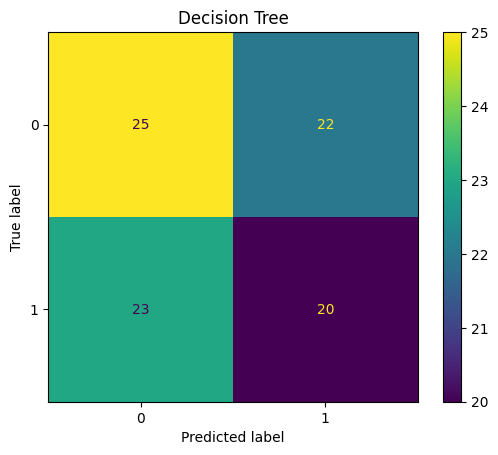

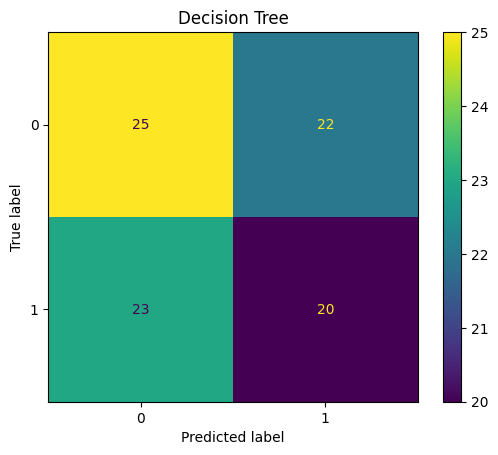


 Cross Validation Accuracy:
Decision tree: 0.4966666666666667
Random Forest: 0.5266666666666666


In [ ]:
#Target with Noise
def irrigation_rule(row):
  if row['Soil']=="Dry" and row["Weather"]!="Rainy":
    base="Yes"
  elif row["Soil"]=="Wet":
    base="No"
  else:
    base=random.choice(["Yes","No"])

  if random.random()<0.2:
    return "No" if base=="Yes" else "Yes"
  return base
df["Irrigate"]=df.apply(irrigation_rule,axis=1)

# encode data
le=LabelEncoder()
for col in df.columns:
  df[col]=le.fit_transform(df[col])

# Step 5 Split data

X=df.drop("Irrigate",axis=1)
y=df["Irrigate"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

# decision tree High varience
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)

y_pred_dt=dt_model.predict(X_test)

# Step 7 Random Forest(Varience Reduction)

rf_model=RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    random_state=42

)

rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)

#Step 8: Accuracu comparision
dt_acc= accuracy_score(y_test,y_pred_dt)
rf_acc= accuracy_score(y_test,y_pred_rf)

print("\n Accuracy Comaprision:")
print("Decision tree accuracy:",dt_acc)
print("Random forest accuracy:",rf_acc)

# step 9: Confusion Matrix
cm_dt=confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_rf=confusion_matrix(y_test,y_pred_rf,labels=[0,1])

print("\n decision tree confusion matrix:\n",cm_dt)
print("\n Random forest confusion matrix:\n",cm_rf)

# step 10 Visual condusion matrix

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt)
plt.title("Decision Tree")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt)
plt.title("Decision Tree")
plt.show()

# Cross validation
dt_cv=cross_val_score(dt_model,X,y, cv=5)
rf_cv=cross_val_score(rf_model,X,y, cv=5)
print("\n Cross Validation Accuracy:")

print("Decision tree:",dt_cv.mean())
print("Random Forest:",rf_cv.mean())





